# Random Forest K-Fold Evaluation

Train only the Random Forest baseline with 5-fold cross-validation.

## Config

Choose the target dataset, feature-drop options, fold count, output directory, and Random Forest hyperparameters here.

In [7]:
from pathlib import Path
import os
import sys
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "k-fold":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "test":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.dataload import (
    PRICE_PATH,
    PRICE_PER_SQFT_PATH,
    drop_addr,
    drop_coord,
    load_df,
    split_X_y,
)
from metrics.adjusted_r2 import adjusted_r2
from metrics.mae import mae
from metrics.mape import mape
from metrics.mse import rmse
from metrics.r2_score import r2_score
from models import TrainConfig
from models.random_forest import RandomForest, RandomForestConfig

# =========================
# Dataset / split settings
# =========================
# Choose one: "price" or "price_per_sqft".
target = ["price", "price_per_sqft"]
TARGET_NAME = target[1]

# Feature ablation switches. This baseline file is configured as 1_1 by default.
DROP_ADDRESS = True
DROP_COORD = True

SEED = 42
N_SPLITS = 5
MODEL_NAME = "baseline_rf"
MODEL_ORDER = [MODEL_NAME]

OUTPUT_DIR = PROJECT_ROOT / "test" / "k-fold" / "folded"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Random Forest hyperparameters
# =========================
RF_HPARAMS = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": None,
}

CONFIG = {
    "project_root": str(PROJECT_ROOT),
    "target_name": TARGET_NAME,
    "drop_address": DROP_ADDRESS,
    "drop_coord": DROP_COORD,
    "seed": SEED,
    "n_splits": N_SPLITS,
    "model_order": MODEL_ORDER,
    "output_dir": str(OUTPUT_DIR.relative_to(PROJECT_ROOT)),
    "hparams": {MODEL_NAME: RF_HPARAMS},
}

CONFIG


{'project_root': 'c:\\Career\\UNIST\\4-1\\Machine Learning\\Project\\house-price-regressor',
 'target_name': 'price_per_sqft',
 'drop_address': True,
 'drop_coord': True,
 'seed': 42,
 'n_splits': 5,
 'model_order': ['baseline_rf'],
 'output_dir': 'test\\k-fold\\folded',
 'hparams': {'baseline_rf': {'n_estimators': 100,
   'max_depth': None,
   'min_samples_split': 2,
   'min_samples_leaf': 2,
   'max_features': None}}}

## Training

Run 5-fold training for Random Forest only. Each fold saves one model file under `test/k-fold/folded`.

In [8]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def target_path(target_name: str) -> str:
    if target_name == "price":
        return PRICE_PATH
    if target_name == "price_per_sqft":
        return PRICE_PER_SQFT_PATH
    raise ValueError("TARGET_NAME must be 'price' or 'price_per_sqft'")


def preprocess_fold(X_train, X_val):
    X_train = X_train.copy()
    X_val = X_val.copy()

    # Random Forest baseline: no target encoding and no feature scaling.
    if DROP_ADDRESS:
        X_train = drop_addr(X_train)
        X_val = drop_addr(X_val)
    if DROP_COORD:
        X_train = drop_coord(X_train)
        X_val = drop_coord(X_val)

    return X_train, X_val


def build_rf_model():
    return RandomForest(RandomForestConfig(model="rf", **RF_HPARAMS))


def train_config_for_rf(X_train, y_train):
    return TrainConfig(X=X_train, y=y_train, epochs=1, lr=0.0, batch_size=None, verbose=False)


def model_settings_text(input_dim: int) -> str:
    compact = dict(RF_HPARAMS)
    compact["input_dim"] = input_dim
    return str(compact)


def metric_dict(y_true, y_pred, n_features: int):
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "R2": r2,
        "Adjusted_R2": adjusted_r2(y_true, y_pred, n_features),
    }


def save_model(fold: int, model):
    path = OUTPUT_DIR / f"baseline_rf{fold}.pth"
    torch.save(model.state_dict(), path)
    return path


set_seed(SEED)
df = load_df(target_path(TARGET_NAME))
X_all, y_all = split_X_y(df, "price")

print(f"target dataset: {TARGET_NAME}")
print(f"drop_address: {DROP_ADDRESS}")
print(f"drop_coord: {DROP_COORD}")
print(f"rows: {len(df)}")
print(f"raw features: {X_all.shape[1]}")


target dataset: price_per_sqft
drop_address: True
drop_coord: True
rows: 3977
raw features: 17


In [9]:
rows = []
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"\n===== {MODEL_NAME.upper()} 5-fold start =====")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_all), start=1):
    set_seed(SEED + fold)

    X_train_raw = X_all.iloc[train_idx].copy()
    X_val_raw = X_all.iloc[val_idx].copy()
    y_train_raw = y_all.iloc[train_idx].copy()
    y_val_raw = y_all.iloc[val_idx].copy()

    X_train, X_val = preprocess_fold(X_train_raw, X_val_raw)
    input_dim = X_train.shape[1]
    model = build_rf_model()
    train_cfg = train_config_for_rf(X_train, y_train_raw)

    fit_start = time.perf_counter()
    model.fit(train_cfg)
    fit_seconds = time.perf_counter() - fit_start

    pred_start = time.perf_counter()
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    predict_seconds = time.perf_counter() - pred_start

    model_path = save_model(fold, model)
    settings = model_settings_text(input_dim)

    for split, y_true, y_pred in [
        ("train", y_train_raw, y_train_pred),
        ("val", y_val_raw, y_val_pred),
    ]:
        metrics = metric_dict(y_true, y_pred, input_dim)
        rows.append(
            {
                "model": MODEL_NAME,
                "fold": fold,
                "split": split,
                "target": TARGET_NAME,
                "drop_address": DROP_ADDRESS,
                "drop_coord": DROP_COORD,
                "n_features": input_dim,
                "settings": settings,
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "model_path": str(model_path.relative_to(PROJECT_ROOT)),
                **metrics,
            }
        )

    print(
        f"baseline_rf{fold}: fit={fit_seconds:.3f}s, "
        f"val MAE={rows[-1]['MAE']:.4f}, val RMSE={rows[-1]['RMSE']:.4f}, "
        f"val R2={rows[-1]['R2']:.4f}, saved={model_path.name}"
    )

results_df = pd.DataFrame(rows)
metrics_path = OUTPUT_DIR / "baseline_rf_kfold_metrics.csv"
results_df.to_csv(metrics_path, index=False)

print("\nSaved metrics:", metrics_path)
print("Saved RF model files:", len(list(OUTPUT_DIR.glob("baseline_rf*.pth"))))



===== BASELINE_RF 5-fold start =====
[RandomForest.fit] Execution time: 2.0646 sec
[RandomForest.predict] Execution time: 0.0781 sec
[RandomForest.predict] Execution time: 0.0322 sec
baseline_rf1: fit=2.065s, val MAE=65.8241, val RMSE=84.6087, val R2=0.3290, saved=baseline_rf1.pth
[RandomForest.fit] Execution time: 2.1429 sec
[RandomForest.predict] Execution time: 0.0669 sec
[RandomForest.predict] Execution time: 0.0273 sec
baseline_rf2: fit=2.143s, val MAE=68.5292, val RMSE=88.6183, val R2=0.2130, saved=baseline_rf2.pth
[RandomForest.fit] Execution time: 2.1067 sec
[RandomForest.predict] Execution time: 0.0865 sec
[RandomForest.predict] Execution time: 0.0316 sec
baseline_rf3: fit=2.107s, val MAE=66.7695, val RMSE=87.6386, val R2=0.2711, saved=baseline_rf3.pth
[RandomForest.fit] Execution time: 2.0111 sec
[RandomForest.predict] Execution time: 0.0795 sec
[RandomForest.predict] Execution time: 0.0363 sec
baseline_rf4: fit=2.012s, val MAE=68.5704, val RMSE=90.3783, val R2=0.2923, saved

## Evaluation

Display fold-level settings, fit time, and validation metrics. Then summarize time and metric stability with mean and standard deviation.

In [10]:
def print_context(block_name: str):
    print(f"[{block_name}]")
    print(f"target dataset: {TARGET_NAME}")
    print(f"drop_address: {DROP_ADDRESS}")
    print(f"drop_coord: {DROP_COORD}")
    print(f"folds: {N_SPLITS}")
    print(f"model order: {MODEL_ORDER}")
    print()


display_cols = [
    "model", "fold", "target", "drop_address", "drop_coord", "n_features",
    "settings", "fit_seconds", "predict_seconds", "MAE", "RMSE", "MAPE",
    "R2", "Adjusted_R2", "model_path",
]

val_report = (
    results_df[results_df["split"].eq("val")]
    .copy()
    .sort_values(["model", "fold"], key=lambda s: s.map({m: i for i, m in enumerate(MODEL_ORDER)}) if s.name == "model" else s)
)

print_context("Fold-level validation table")
val_report[display_cols]


[Fold-level validation table]
target dataset: price_per_sqft
drop_address: True
drop_coord: True
folds: 5
model order: ['baseline_rf']



,model,fold,target,drop_address,drop_coord,n_features,settings,fit_seconds,predict_seconds,MAE,RMSE,MAPE,R2,Adjusted_R2,model_path
1,baseline_rf,1,price_per_sqft,True,True,12,"{'n_estimators': 100, 'max_depth': None, 'min_...",2.065405,0.110484,65.824074,84.608653,32.840798,0.329048,0.318765,test\k-fold\folded\baseline_rf1.pth
3,baseline_rf,2,price_per_sqft,True,True,12,"{'n_estimators': 100, 'max_depth': None, 'min_...",2.143494,0.094362,68.529184,88.618265,31.534588,0.213027,0.200966,test\k-fold\folded\baseline_rf2.pth
5,baseline_rf,3,price_per_sqft,True,True,12,"{'n_estimators': 100, 'max_depth': None, 'min_...",2.107368,0.118284,66.769472,87.638567,30.361308,0.271080,0.259895,test\k-fold\folded\baseline_rf3.pth
7,baseline_rf,4,price_per_sqft,True,True,12,"{'n_estimators': 100, 'max_depth': None, 'min_...",2.011703,0.115948,68.570439,90.378252,30.373445,0.292276,0.281416,test\k-fold\folded\baseline_rf4.pth
9,baseline_rf,5,price_per_sqft,True,True,12,"{'n_estimators': 100, 'max_depth': None, 'min_...",2.002635,0.124195,66.098464,85.444110,30.327833,0.287643,0.276712,test\k-fold\folded\baseline_rf5.pth


[Time summary table and graph]
target dataset: price_per_sqft
drop_address: True
drop_coord: True
folds: 5
model order: ['baseline_rf']



fit_seconds           predict_seconds          
                   mean       std            mean       std
model                                                      
baseline_rf    2.066121  0.060581        0.112655  0.011347

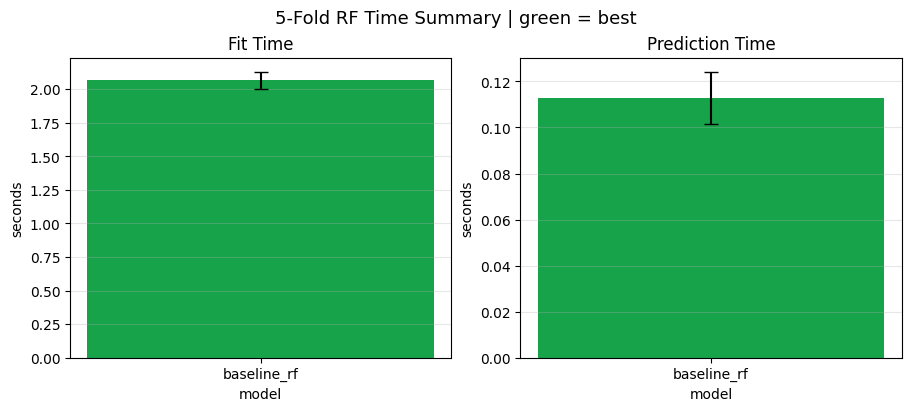

In [11]:
print_context("Time summary table and graph")

def winner_colors(stats, higher_is_better=False):
    best_model = stats["mean"].idxmax() if higher_is_better else stats["mean"].idxmin()
    return ["#16a34a" if model == best_model else "#94a3b8" for model in stats.index]


time_summary = (
    val_report.groupby("model")[["fit_seconds", "predict_seconds"]]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

display(time_summary)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for ax, col, title in [
    (axes[0], "fit_seconds", "Fit Time"),
    (axes[1], "predict_seconds", "Prediction Time"),
]:
    stats = val_report.groupby("model")[col].agg(["mean", "std"]).reindex(MODEL_ORDER)
    colors = winner_colors(stats, higher_is_better=False)
    ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=colors)
    ax.set_title(title)
    ax.set_xlabel("model")
    ax.set_ylabel("seconds")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("5-Fold RF Time Summary | green = best", fontsize=13)
plt.show()


[Metric summary table and graph]
target dataset: price_per_sqft
drop_address: True
drop_coord: True
folds: 5
model order: ['baseline_rf']



MAE                RMSE                 MAPE            \
                  mean      std       mean       std       mean       std   
model                                                                       
baseline_rf  67.158327  1.31606  87.337569  2.345672  31.087594  1.105471   

                   R2           Adjusted_R2            
                 mean       std        mean       std  
model                                                  
baseline_rf  0.278615  0.042338    0.267551  0.042986

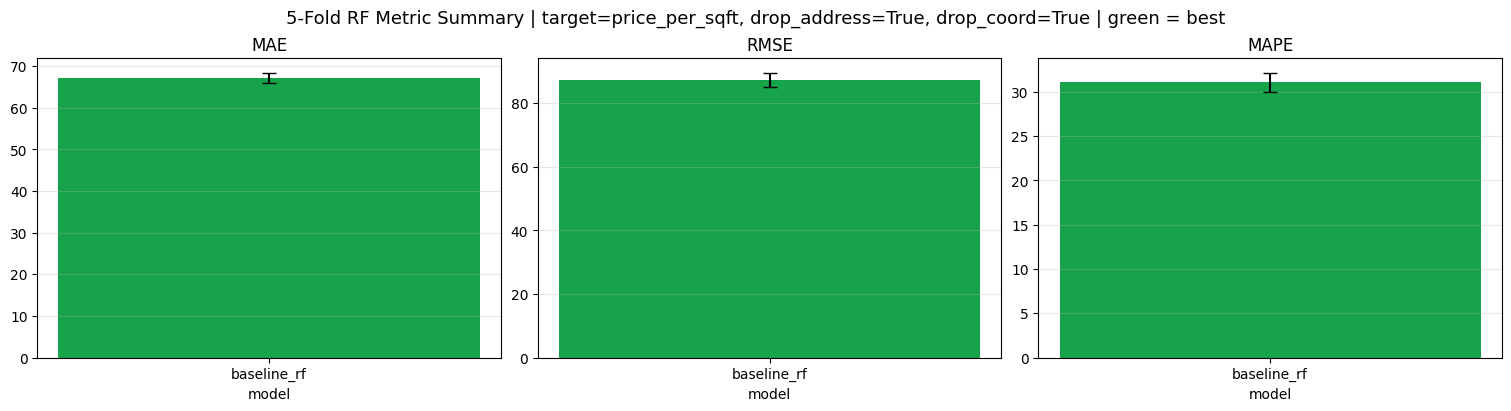

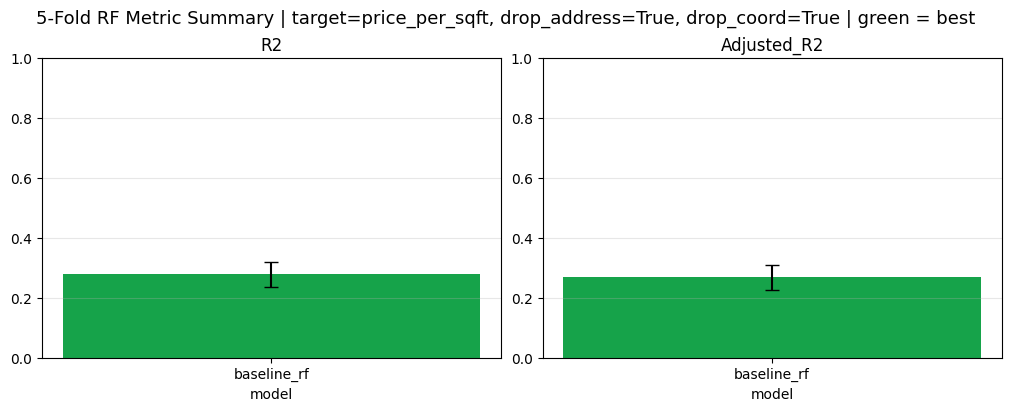

In [12]:
print_context("Metric summary table and graph")

def winner_colors(stats, higher_is_better):
    best_model = stats["mean"].idxmax() if higher_is_better else stats["mean"].idxmin()
    return ["#16a34a" if model == best_model else "#94a3b8" for model in stats.index]


metric_order = ["MAE", "RMSE", "MAPE", "R2", "Adjusted_R2"]
higher_is_better = {
    "MAE": False,
    "RMSE": False,
    "MAPE": False,
    "R2": True,
    "Adjusted_R2": True,
}

metric_summary = (
    val_report.groupby("model")[metric_order]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

display(metric_summary)

metric_groups = [
    ["MAE", "RMSE", "MAPE"],
    ["R2", "Adjusted_R2"],
]

for group in metric_groups:
    fig, axes = plt.subplots(1, len(group), figsize=(5 * len(group), 4), constrained_layout=True)
    if len(group) == 1:
        axes = [axes]
    for ax, metric in zip(axes, group):
        stats = val_report.groupby("model")[metric].agg(["mean", "std"]).reindex(MODEL_ORDER)
        colors = winner_colors(stats, higher_is_better=higher_is_better[metric])
        ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=colors)
        ax.set_title(metric)
        ax.set_xlabel("model")
        ax.grid(axis="y", alpha=0.3)
        if metric in {"R2", "Adjusted_R2"}:
            low = min(0, float((stats["mean"].fillna(0)).min()) - 0.05)
            ax.set_ylim(low, 1.0)

    fig.suptitle(
        f"5-Fold RF Metric Summary | target={TARGET_NAME}, "
        f"drop_address={DROP_ADDRESS}, drop_coord={DROP_COORD} | green = best",
        fontsize=13,
    )
    plt.show()
